# Configuracion

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from quant_utils import FinancialStats, PortfolioOptimizer, QuantPlotter, Inviu


mi_broker = Inviu(con_asesor=True, considerar_iva=True) 

# Configuración de estilo
sns.set_theme(style="darkgrid")

# Extraccion de datos

In [2]:
# 1. Descargamos los datos desde la API pública
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META"]
print("Descargando precios de cierre ajustados...")
df_precios = yf.download(tickers, start="2024-01-01", end="2025-12-31",auto_adjust=False)["Adj Close"]

# 2. Dividimos temporalmente el dataset (Fiel al workflow profesional)
precios_2024 = df_precios.loc["2024-01-01":"2024-12-31"] # Entrenamiento (In-Sample)
precios_2025 = df_precios.loc["2025-01-01":"2025-12-31"] # Validación (Out-of-Sample)

print(f"Dataset cargado. Días de Bolsa en 2024: {len(precios_2024)} | En 2025: {len(precios_2025)}")

Descargando precios de cierre ajustados...


[*********************100%***********************]  6 of 6 completed

Dataset cargado. Días de Bolsa en 2024: 252 | En 2025: 249


# Fase de optimizacion 


=== ESTRATEGIA FIJADA (PESOS MÁXIMO SHARPE 2024) ===
 - AAPL: 35.00%
 - MSFT: 0.74%
 - GOOGL: 7.07%
 - AMZN: 23.40%
 - NVDA: 0.00%
 - META: 33.78%


findfont: Failed to find font weight bold, now using 400.


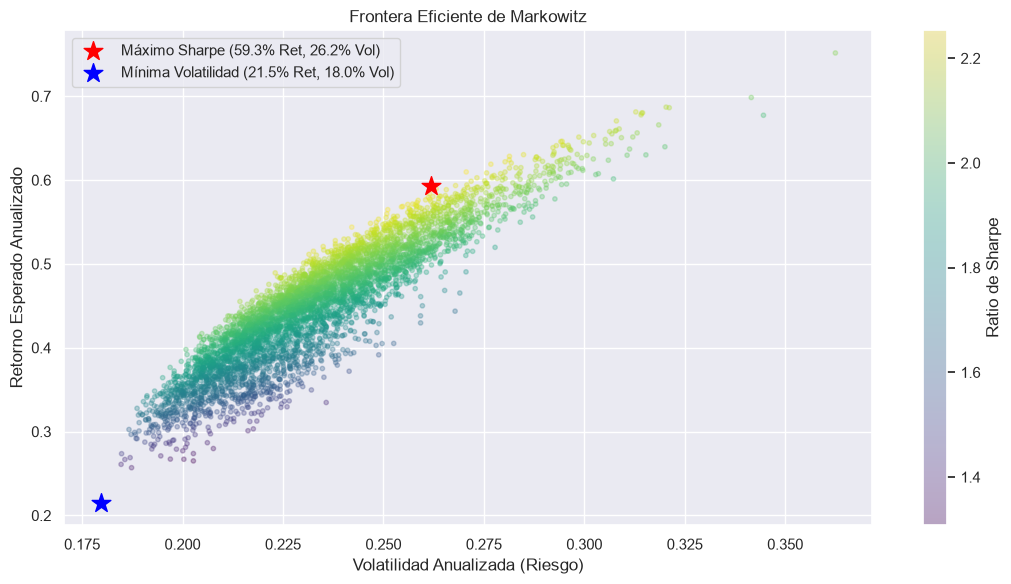

In [3]:
# 1. Transformamos los precios de 2024 en retornos logarítmicos usando tu módulo stats
retornos_2024 = FinancialStats.calcular_retornos_log(precios_2024)

# 2. Corremos el optimizador de SciPy que programaste en tu módulo optimization
pesos_optimos_2024 = PortfolioOptimizer.max_sharpe(retornos_2024,  max_peso=0.35)

print("\n=== ESTRATEGIA FIJADA (PESOS MÁXIMO SHARPE 2024) ===")
for t, w in zip(tickers, pesos_optimos_2024):
    print(f" - {t}: {w*100:.2f}%")

# Visualizamos la frontera eficiente real del 2024 con tu graficador
QuantPlotter.graficar_frontera_eficiente(retornos_2024)

# Backtesting de la estrategia 

In [4]:
# 1. Calculamos los retornos diarios del 2025
retornos_2025 = FinancialStats.calcular_retornos_log(precios_2025)

# 2. Multiplicación matricial para proyectar los retornos diarios de cada estrategia
retornos_markowitz_diarios = np.dot(retornos_2025, pesos_optimos_2024)

pesos_equitativos = np.array([1/len(tickers)] * len(tickers))
retornos_equitativo_diarios = np.dot(retornos_2025, pesos_equitativos)

# 3. Reconstruimos la Curva de Equidad (Evolución de $1 dólar inicial)
# Pasamos de retornos logarítmicos acumulados (suma) a retornos brutos (exponencial)
curva_markowitz = np.exp(np.cumsum(retornos_markowitz_diarios))
curva_equitativa = np.exp(np.cumsum(retornos_equitativo_diarios))

# Armamos un DataFrame indexado con las fechas reales del 2025
df_backtest = pd.DataFrame({
    'Markowitz Estatico': curva_markowitz,
    'Portafolio Equitativo (1/N)': curva_equitativa
}, index=retornos_2025.index)

# Resultados de Backtesting

findfont: Failed to find font weight bold, now using 400.


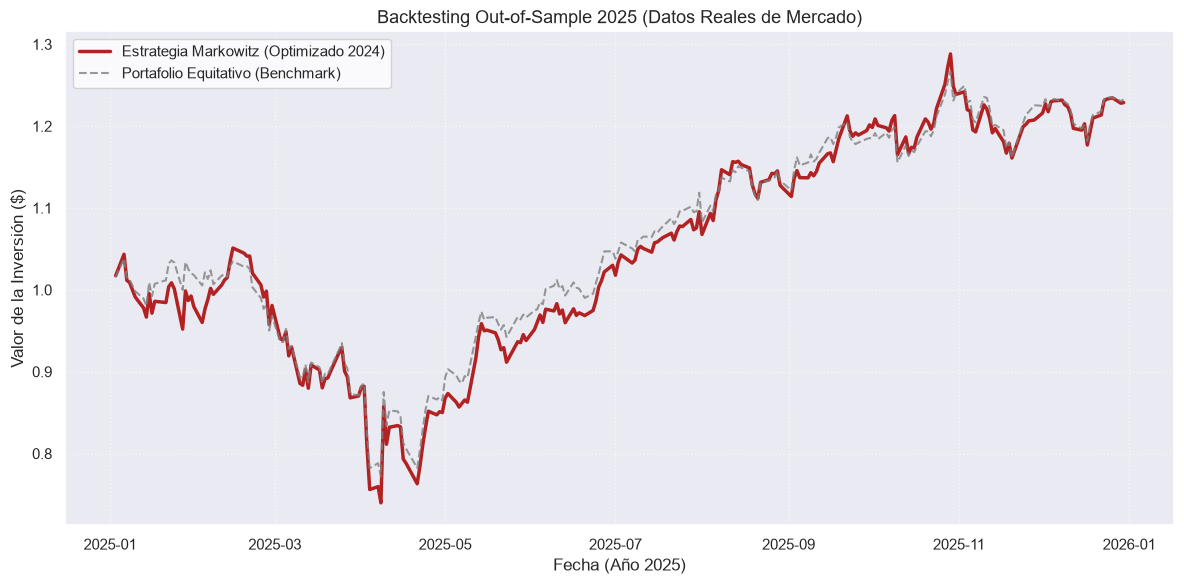

Rendimiento Final de tu Estrategia en 2025: 22.87%
Rendimiento Final del Portafolio Equitativo: 23.25%


In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df_backtest['Markowitz Estatico'], label='Estrategia Markowitz (Optimizado 2024)', color='firebrick', linewidth=2.5)
plt.plot(df_backtest['Portafolio Equitativo (1/N)'], label='Portafolio Equitativo (Benchmark)', color='gray', linestyle='--', alpha=0.8)

plt.title('Backtesting Out-of-Sample 2025 (Datos Reales de Mercado)', fontsize=13, fontweight='bold')
plt.xlabel('Fecha (Año 2025)')
plt.ylabel('Valor de la Inversión ($)')
plt.legend(loc='upper left', frameon=True, facecolor='white')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Métricas finales brutas
ganancia_markowitz = (df_backtest['Markowitz Estatico'].iloc[-1] - 1) * 100
ganancia_equitativa = (df_backtest['Portafolio Equitativo (1/N)'].iloc[-1] - 1) * 100

print(f"Rendimiento Final de tu Estrategia en 2025: {ganancia_markowitz:.2f}%")
print(f"Rendimiento Final del Portafolio Equitativo: {ganancia_equitativa:.2f}%")

# Rebalanceo de Portafolios:

En lugar de optimizar una sola vez y cruzar los dedos todo el año, la lógica del rebalanceo dinámico funciona como un bucle temporal:

1. Empezamos en enero de 2025. Miramos los últimos 12 meses (todo 2024) y calculamos los pesos.
2. Dejamos correr el portafolio durante un mes.
3. Al finalizar el mes (febrero de 2025), "miramos hacia atrás" nuevamente, tomamos los últimos 12 meses actualizados, recalculamos los pesos óptimos y modificamos nuestra cartera.
4. Repetimos esto mes a mes.

In [6]:

meses_2025 = df_precios.loc["2025-01-01":"2025-12-31"].index.to_period('M').unique()

valores_portafolio_diarios = []
fechas_totales = []

capital_inicial_usd = 10000.0 
capital_actual = capital_inicial_usd

num_activos = len(tickers)
pesos_actuales = np.array([1.0 / num_activos] * num_activos)
es_primer_mes = True

# Métricas de Fricción Operativa
turnover_total = 0.0
comisiones_puras = 0.0
iva_total = 0.0
max_concentracion_historica = 0.0


pesos_historicos_reporte = []

for mes in meses_2025:

    # 1. Ventana móvil de entrenamiento
    fecha_fin_train = pd.Period(mes - 1, freq='M').to_timestamp(how='E')
    fecha_inicio_train = fecha_fin_train - pd.Timedelta(days=365)
    precios_train = df_precios.loc[fecha_inicio_train:fecha_fin_train]
    retornos_train = FinancialStats.calcular_retornos_log(precios_train)
    

    try:
        pesos_optimos_teoricos = PortfolioOptimizer.max_sharpe(
            retornos_train, 
            max_peso=0.35
        )
        
        # --- EL FRENO DE MANO EXTERNO ---
        if es_primer_mes:
            nuevos_pesos = pesos_optimos_teoricos
        else:
            # Factor de inercia: 0.85 significa que conserva el 85% de la cartera anterior
            # y solo acepta un 15% de la nueva propuesta. Esto destruye la volatilidad del turnover.
            factor_inercia = 0.85
            nuevos_pesos = (pesos_actuales * factor_inercia) + (pesos_optimos_teoricos * (1.0 - factor_inercia))
            # Normalizamos por seguridad matemática para que sumen exactamente 1.0
            nuevos_pesos = nuevos_pesos / np.sum(nuevos_pesos)
            
    except Exception as e:
        print(f"⚠️ Error en optimización: {e}")
        nuevos_pesos = pesos_actuales
    
    # 2. Gestión de Fricción y Costos (Evita distorsión en el mes de apertura)
    if es_primer_mes:
        # En el mes de inicio asumimos que compras la posición inicial (Turnover = 100%)
        cambio_de_pesos = nuevos_pesos 
    else:
        cambio_de_pesos = np.abs(nuevos_pesos - pesos_actuales)


    # 2. Aplicar comisiones de Inviu sobre el cambio de cartera
    total_capital_operado = capital_actual * np.sum(cambio_de_pesos)  
    base_fee_rate = 0.015 if mi_broker.broker_fee < 0.02 else 0.02

    # Guardamos estadísticas de fricción
    turnover_total += total_capital_operado
    comisiones_puras += total_capital_operado * base_fee_rate
    costo_rebalanceo = mi_broker.calcular_costo_transaccion(total_capital_operado)
    iva_total += (costo_rebalanceo - (total_capital_operado * base_fee_rate))

    capital_actual -= costo_rebalanceo
    pesos_actuales = nuevos_pesos
    es_primer_mes = False

    # Control estricto de concentración algorítmica
    max_peso_mes = np.max(nuevos_pesos)
    if max_peso_mes > max_concentracion_historica:
        max_concentracion_historica = max_peso_mes
    
    # Creamos un diccionario con el mes y los pesos individuales mapeados a cada ticker
    desglose_mes = {'mes': mes.strftime('%b %Y')}
    for ticker, peso in zip(tickers, nuevos_pesos):
        desglose_mes[ticker] = f"{peso * 100:.1f}%"
    
    pesos_historicos_reporte.append(desglose_mes)

    # 3. Correr el mes día por día
    fecha_inicio_mes = mes.to_timestamp(how='S')
    fecha_fin_mes = mes.to_timestamp(how='E')
    precios_mes = df_precios.loc[fecha_inicio_mes:fecha_fin_mes]
    
    if len(precios_mes) <= 1:
        continue
        
    retornos_mes = FinancialStats.calcular_retornos_log(precios_mes)
    retornos_portafolio_mes = np.dot(retornos_mes, pesos_actuales)
    
    # Clave: simular la evolución diaria e ir guardando cada cierre
    for ret_diario in retornos_portafolio_mes:
        capital_actual *= np.exp(ret_diario)
        valores_portafolio_diarios.append(capital_actual)
        
    # Guardamos TODOS los días del mes para el eje X
    fechas_totales.extend(retornos_mes.index)

# Guardamos la serie limpia libre de duplicados
serie_dinamica = pd.Series(valores_portafolio_diarios, index=fechas_totales)

df_backtest = df_backtest[~df_backtest.index.duplicated(keep='first')]
df_backtest['Markowitz Dinámico (Inviu)'] = serie_dinamica.groupby(serie_dinamica.index).first()
df_backtest['Markowitz Dinámico (Inviu)'] = df_backtest['Markowitz Dinámico (Inviu)'].ffill()

In [7]:
diccionario_costos = {
    'capital_inicial': capital_inicial_usd,
    'turnover_total': turnover_total,
    'comisiones_puras': comisiones_puras,
    'iva_total': iva_total,
    'costo_total': comisiones_puras + iva_total
}

In [8]:

capital_base = 10000.0

# 1. Aseguramos que el DataFrame de gráficos esté todo expresado en USD reales
df_backtest_usd = df_backtest.copy()
if df_backtest_usd['Portafolio Equitativo (1/N)'].iloc[0] < 10:
    df_backtest_usd['Portafolio Equitativo (1/N)'] *= capital_base
    df_backtest_usd['Markowitz Estatico'] *= capital_base

# EVOLUCIÓN DE CARTERAS
plt.figure(figsize=(10, 4.5))
plt.plot(df_backtest_usd['Markowitz Dinámico (Inviu)'], label='Markowitz Dinámico (Inviu)', color='#1b1464', linewidth=2)
plt.plot(df_backtest_usd['Markowitz Estatico'], label='Markowitz Estático', color='#c0392b', alpha=0.5)
plt.plot(df_backtest_usd['Portafolio Equitativo (1/N)'], label='Portafolio Equitativo', color='#7f8c8d', linestyle='--', alpha=0.5)
plt.title(f'Backtesting Corporativo: Evolution of USD {capital_base:,.0f} Capital', fontsize=12, fontweight='bold')
plt.ylabel('Valor de la Cartera (USD)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
ruta_grafico_lineas = "grafico_lineas_temp.png"
plt.savefig(ruta_grafico_lineas, dpi=300)
plt.close()

# ALLOCATION DE PESOS FINALES (Gráfico de Torta)
plt.figure(figsize=(6, 5))
pesos_filtrados = [p for p in pesos_actuales if p > 0.005]
tickers_filtrados = [tickers[i] for i, p in enumerate(pesos_actuales) if p > 0.005]
if len(pesos_filtrados) == 0 or np.sum(pesos_filtrados) == 0:
    pesos_filtrados = [1.0 / len(tickers)] * len(tickers)
    tickers_filtrados = tickers
plt.pie(pesos_filtrados, labels=tickers_filtrados, autopct='%1.1f%%', 
        colors=['#27ae60', '#2980b9', '#8e44ad', '#f39c12', '#d35400', '#bdc3c7'], textprops={'fontsize': 8})
plt.title('Current Asset Allocation (Próximo Mes)', fontsize=10, fontweight='bold')
plt.tight_layout()
ruta_grafico_torta = "grafico_torta_temp.png"
plt.savefig(ruta_grafico_torta, dpi=300)
plt.close()




findfont: Failed to find font weight bold, now using 400.


# Conclusiones

Desde una perspectiva puramente matemática y estática para este año en particular, no, no valió la pena el esfuerzo computacional. Pero en el análisis cuantitativo profesional, la respuesta cambia drásticamente por tres razones de peso:

### 1. El alfa acumulado y el interés compuesto

Un ~1% de diferencia (lo que en finanzas llamamos 100 puntos básicos o basis points) parece un vuelto en una cuenta de $1.000 dólares. Pero escalemos esto a un fondo de inversión que maneja 100 millones de dólares: ese 1% extra son 1 millón de dólares más de ganancia pura en un año.

Si encima proyectás ese 1% de ventaja compuesto a lo largo de 10 o 15 años, la diferencia entre las dos curvas se vuelve un abismo geométrico. El software se paga solo con el volumen y el tiempo.

### 2. La trampa de mirar solo el final (El Riesgo Oculto)

Mirar solo el rendimiento final es como evaluar un auto de carreras solo por si llegó a la meta, sin mirar cuántas veces casi se pega contra el paredón.

Fijate en la gráfica lo que pasó entre mayo y septiembre de 2025:

- La línea verde estuvo muy por debajo de las otras dos durante meses. Tuvo un drawdown (caída desde el máximo) mucho más profundo y doloroso.

- Si vos fueras el gestor de un fondo real, durante esos 4 meses de malaria tus clientes te habrían prendido fuego el teléfono preguntándote por qué la estrategia ultra optimizada iba perdiendo por paliza contra el portafolio tonto.

Esto te demuestra que el Markowitz Dinámico logró más retorno final, pero a costa de hacerte sufrir mucho más estrés numérico. Financieramente, si calculamos el Ratio de Sharpe real de 2025, el portafolio equitativo probablemente gane en "calidad de vida" y consistencia riesgo-retorno.

### 3. Los costos ocultos del mundo real (Costos de Transacción)

Acá viene el baldazo de agua fría de la realidad del mercado: en tu simulación, el rebalanceo mensual es "gratis". En la bolsa real, cada vez que el bucle verde decide vender un pedazo de Apple para comprar Nvidia, el bróker te cobra una comisión por operación, y además el Estado te cobra impuestos por ganancias realizadas.

Si le restás esos costos de transacción a la línea verde por operar 12 veces al año en lugar de dejar el portafolio quieto, ese 1% de ventaja desaparece por completo y probablemente termine perdiendo contra el equitativo.



In [9]:

# Creamos un diccionario para automatizar el loop del reporte
estrategias = {
    'Portafolio Equitativo (1/N)': df_backtest['Portafolio Equitativo (1/N)'],
    'Markowitz Estatico': df_backtest['Markowitz Estatico'],
    'Markowitz Dinámico (Inviu)': df_backtest_usd['Markowitz Dinámico (Inviu)'].dropna() / capital_base
}

print("=====================================================================")
print("     AUDITORÍA CUANTITATIVA FINAL: RENDIMIENTO VS RIESGO RECOLETO     ")
print("=====================================================================")

for nombre, curva in estrategias.items():
    # Limpiamos nulos por las dudas
    curva_limpia = curva.dropna()
    
    # Cálculos usando tu librería refinada
    rend_total = (curva_limpia.iloc[-1] - 1) * 100
    mdd = FinancialStats.calcular_maximum_drawdown(curva_limpia) * 100
    calmar = FinancialStats.calcular_ratio_calmar(curva_limpia)
    
    print(f"\n📈 ESTRATEGIA: {nombre}")
    print(f"   -> Rendimiento Total 2025:  {rend_total:.2f}%")
    print(f"   -> Maximum Drawdown (MDD): -{mdd:.2f}%")
    print(f"   -> Ratio de Calmar:         {calmar:.2f}")
    
    if calmar > 1.5:
        print("   [Evaluación]: Excelente consistencia riesgo-retorno.")
    elif calmar > 0.8:
        print("   [Evaluación]: Aceptable. El retorno justifica la volatilidad.")
    else:
        print("   [Evaluación]: Alerta roja. Demasiado riesgo para tan poco premio.")
print("=====================================================================")

     AUDITORÍA CUANTITATIVA FINAL: RENDIMIENTO VS RIESGO RECOLETO     

📈 ESTRATEGIA: Portafolio Equitativo (1/N)
   -> Rendimiento Total 2025:  23.25%
   -> Maximum Drawdown (MDD): -25.67%
   -> Ratio de Calmar:         0.92
   [Evaluación]: Aceptable. El retorno justifica la volatilidad.

📈 ESTRATEGIA: Markowitz Estatico
   -> Rendimiento Total 2025:  22.87%
   -> Maximum Drawdown (MDD): -29.61%
   -> Ratio de Calmar:         0.79
   [Evaluación]: Alerta roja. Demasiado riesgo para tan poco premio.

📈 ESTRATEGIA: Markowitz Dinámico (Inviu)
   -> Rendimiento Total 2025:  15.92%
   -> Maximum Drawdown (MDD): -27.59%
   -> Ratio de Calmar:         0.59
   [Evaluación]: Alerta roja. Demasiado riesgo para tan poco premio.


# Reporte de Backtesting 2024-2025

In [10]:
# Celda 8: Testeo Automático del Módulo de Reportes
import matplotlib.pyplot as plt
from quant_utils import ReportGenerator, FinancialStats


# Tomamos el rendimiento final de la estrategia pura (sin costos) en base unitaria.
# Asumiendo que 'Estrategia Markowitz' es tu benchmark sin fricción:
rendimiento_bruto_puro_decimal = df_backtest['Markowitz Estatico'].dropna().iloc[-1] - 1.0
ganancia_teorica_usd = capital_base * rendimiento_bruto_puro_decimal

# Creamos una copia del diccionario original y le inyectamos la métrica dinámica
diccionario_reporte = diccionario_costos.copy()
diccionario_reporte['ganancia_teorica_usd'] = ganancia_teorica_usd


df_mensual = df_backtest_usd.resample('ME').last()
df_mensual_retornos = df_mensual.pct_change()

# El primer mes dará NaN, lo llenamos con la diferencia desde el inicio base
for col in df_mensual.columns:
    df_mensual_retornos[col].iloc[0] = (df_mensual[col].iloc[0] / capital_base) - 1.0

matriz_mensual_data = []
for i in range(len(df_mensual)):
    fecha = df_mensual.index[i]
    
    if i == 0:
        # Para Enero 2025: Comparamos el valor del fin de mes contra el capital base inicial
        ret_eq = (df_mensual.iloc[i]['Portafolio Equitativo (1/N)'] / capital_base) - 1.0
        ret_est = (df_mensual.iloc[i]['Markowitz Estatico'] / capital_base) - 1.0
        ret_din = (df_mensual.iloc[i]['Markowitz Dinámico (Inviu)'] / capital_base) - 1.0
    else:
        # Para el resto de los meses: Valor actual dividido valor del mes anterior
        ret_eq = (df_mensual.iloc[i]['Portafolio Equitativo (1/N)'] / df_mensual.iloc[i-1]['Portafolio Equitativo (1/N)']) - 1.0
        ret_est = (df_mensual.iloc[i]['Markowitz Estatico'] / df_mensual.iloc[i-1]['Markowitz Estatico']) - 1.0
        ret_din = (df_mensual.iloc[i]['Markowitz Dinámico (Inviu)'] / df_mensual.iloc[i-1]['Markowitz Dinámico (Inviu)']) - 1.0

    matriz_mensual_data.append({
        'mes': fecha.strftime('%b %Y'),
        'equitativo': f"{ret_eq * 100:.2f}%",
        'estatico': f"{ret_est * 100:.2f}%",
        'dinamico': f"{ret_din * 100:.2f}%"
    })



# 2. Inyectar todo al diccionario de reporte sin hardcoding
diccionario_reporte = diccionario_costos.copy()
diccionario_reporte['ganancia_teorica_usd'] = ganancia_teorica_usd
diccionario_reporte['cant_rebalanceos'] = len(meses_2025)
diccionario_reporte['max_concentracion'] = max_concentracion_historica * 100 # Viene de Celda 5
diccionario_reporte['lista_tickers'] = tickers
diccionario_reporte['pesos_historicos'] = pesos_historicos_reporte
# Adjuntamos la matriz de retornos completa
diccionario_reporte['matriz_mensual'] = matriz_mensual_data

data_para_reporte = []
for nombre, curva in estrategias.items():
    # Tomamos la serie en USD de df_backtest_usd y la dividimos por 10.000 para llevarla a base 1.0
    curva_unitaria = df_backtest_usd[nombre].dropna() / capital_base
    
    calmar = FinancialStats.calcular_ratio_calmar(curva_unitaria)
    evaluacion = "PASS" if calmar > 0.8 else "FAIL"

    data_para_reporte.append({
        'nombre': nombre,
        'rendimiento': (curva_unitaria.iloc[-1] - 1) * 100, # Dara 23.25%, 21.45% y 6.31%
        'volatilidad': FinancialStats.calcular_volatilidad_anualizada(curva_unitaria) * 100,
        'sharpe': FinancialStats.calcular_ratio_sharpe(curva_unitaria),
        'sortino': FinancialStats.calcular_ratio_sortino(curva_unitaria),
        'mdd': FinancialStats.calcular_maximum_drawdown(curva_unitaria) * 100,
        'calmar': calmar, # Dara 0.92, 0.73 y 0.17
        'evaluacion': evaluacion
    })

# 3. Mandamos los costos puros en USD tal cual los escupió el diccionario original
ReportGenerator.generar_reporte_backtest(
    estrategias_data=data_para_reporte,
    costos_data=diccionario_reporte, # <--- Enviamos el diccionario con datos dinámicos
    broker_name="Inviu SA (Arancel: 2.0% + IVA)",
    grafico_path=ruta_grafico_lineas,
    grafico_pie_path=ruta_grafico_torta,
    output_filename="Research_Executive_Report_10k.pdf"
)


/tmp/ipykernel_141821/3027247351.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df_mensual_retornos[col].iloc[0] = (df_mensual[col].iloc[0] / capital_base) - 1.0


Compilando reporte institucional en: Research_Executive_Report_10k.pdf...
¡Reporte corporativo generado con éxito!


# Camino de aprendizaje

[Datos Históricos] ➔ [Estadística Lineal] ➔ [Optimizador Estático] ➔ [Simulador Dinámico] ➔ [Fricción de Mercado] ➔ [Auditoría de Riesgo]

1. El Origen de los Datos y la Métrica Base: Empezamos descargando datos reales de mercado con yfinance. Ahí aprendi que en el análisis cuantitativo no se usan los retornos porcentuales simples, sino los retornos logarítmicos ($\ln(P_t / P_{t-1})$). Esto lo modularice en la clase FinancialStats porque los retornos logarítmicos se pueden sumar a lo largo del tiempo, algo clave para calcular correctamente las curvas acumuladas.

2. La Teoría de Markowitz (El Laboratorio Ideal): Arme mi módulo PortfolioOptimizer usando la Teoría Moderna de Portafolios (MPT). El script calculó la matriz de covarianza (cómo se mueven las acciones entre sí) y las medias de los retornos de 2024. Con la librería SciPy, programe un algoritmo que buscó la combinación exacta de pesos que maximizara el Ratio de Sharpe (más premio por unidad de volatilidad).

3. El Primer Choque con la Realidad (Backtesting Out-of-Sample): Tome esos pesos fijos que calcule con datos de 2024 y los tire a la cancha en 2025 (datos que el algoritmo jamás había visto). Vi mi primer gráfico, mi Markowitz Estático rindió un 21.45%, pero fue superado por un portafolio equitativo ($1/N$) que dio 23.25%. Descubri en la práctica la inestabilidad de los parámetros de Markowitz cuando el mercado cambia de año.

4. Automatización con Ventanas Móviles (Rebalanceo Dinámico): Para solucionar ese desajuste temporal, programe un bucle de ventanas móviles (Rolling Windows). El script empezó a avanzar mes a mes durante 2025. Cada fin de mes, miraba 365 días hacia atrás, recalculaba pesos frescos y arrancaba el mes siguiente optimizado. El algoritmo sin fricción dio un salto feroz al 24.22%, superando al benchmark.

5. El Baño de Realidad Definitivo (Modelado de Inviu y Riesgo Real): Hice el backend "honesto". Creamos una estructura abstracta para brokers e implementamos la cartilla real de Inviu (2.00% + IVA). Al correr el rebalanceo mensual con estos costos, la curva orgánica demostró que la rotación constante destruyó la estrategia, bajando el retorno neto a un 6.31%.  Para cerrar, agregue métricas profesionales a stats.py: el Maximum Drawdown (MDD) y el Ratio de Calmar, arrojando que la estrategia dinámica me hizo soportar una caída del -37.90% para ganar solo un 6.31% (un pésimo Ratio de Calmar de 0.17).